# Writing your own Neural Network code

In [1]:
import autograd.numpy as np
import pandas as pd
import time
from sklearn.model_selection import train_test_split

# custom imports
from source.runge_preprocessing import x, x_train, x_train_scaled, x_test, y, y_noise, y_train, y_test, _dim, activations, activations_derivative, ETA_VALUES, LAMBDA_VALUES, MOMENTUM, RUNGE_MAX_ITERATIONS, VERBOSE, NP_RANDOM_SEED, activations_50, activations_derivative_50, _dim50
from source.neural_network import NN
import source.schedulers as schedulers
from source.cost_functions import mse


# TO DO and notes for part B

Only MSE as cost function in NN
    default in NN

flexible nodes and hidden layers
    OK

only sigmoid
    OK

initialize weights with normal distrubution
    yes

how to initialize bias?
    quite similar as weights..? 
    only one bias per node added to the neuron after weghted sum of inputs, (where weights are hidden * nodes). Bias shifts the fit of data

which activation for output layer?
    linear

how to set up design matrix?
    only as input features

Train and compare with OLS
    use same data set which gave the best score
    ----> analytical, gradient descent?

Compare with FFNN with both 50, and 50 and 100 hidden nodes

comment results and critical discussion

analyse learning rate to find optimal MSE score
    test SGD, RMSprop and ADAM

scale data
    OK



# OLS regression

### Results from project 1
Results from running code in project 1, jupyter file "assignment1_a_b.ipynb"

In section "Explore OLS in regards to polynomial degree, with noise" a small code were added to get smallest MSE Test value, and index for which polynomial degree.

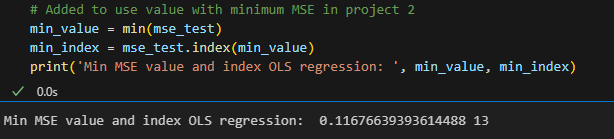

Hence, the best MSE on the test dataset was achieved when using polynomial degree 14.

# OLS gradient descent

From report 1 best results are acheived with learning rate 0.5 and 600 iterations. This can be seen in figure 8

In [2]:

MAX_ITERATIONS = 600
ETA= 0.5    # eta 0.5 in runge_preprocessing ETAs?
mse_formula = mse().cost

# Hidden layers (50, 100)
print(f'Dimensions of input, hidden, and output layer:\n{_dim}')
optimizer_ADAM = schedulers.ADAM(eta=ETA, rho=0, rho2=0) 
optimizer_momentum = schedulers.momentum(eta=ETA, momentum=MOMENTUM)
optimizer_RMSprop = schedulers.RMSprop(eta=ETA,rho=0)

runge_OLS_NN = NN(dims = _dim, activation_funcs = activations, activation_ders = activations_derivative)
epoch_scores, predictions = runge_OLS_NN.fit(X=x_train_scaled, 
                 t=y_train, 
                X_val=x_test, 
                t_val=y_test, 
                epochs=MAX_ITERATIONS, 
                scheduler=optimizer_ADAM)

mse_NN_ADAM = mse_formula(y_true=y_test, y_pred=predictions)
print(mse_NN_ADAM)


epoch_scores, predictions = runge_OLS_NN.fit(X=x_train_scaled, 
                 t=y_train, 
                X_val=x_test, 
                t_val=y_test, 
                epochs=MAX_ITERATIONS, 
                scheduler=optimizer_momentum)


mse_NN_SGD = mse_formula(y_true=y_test, y_pred=predictions)
print(mse_NN_SGD)


epoch_scores, predictions = runge_OLS_NN.fit(X=x_train_scaled, 
                 t=y_train, 
                X_val=x_test, 
                t_val=y_test, 
                epochs=MAX_ITERATIONS, 
                scheduler=optimizer_RMSprop)


mse_NN_RMSprop = mse_formula(y_true=y_test, y_pred=predictions)
print(mse_NN_RMSprop)




# Hidden layers (50,)
print()
print(f'Dimensions of input, hidden, and output layer:\n{_dim50}')
optimizer_ADAM = schedulers.ADAM(eta=ETA, rho=0, rho2=0) 
optimizer_momentum = schedulers.momentum(eta=ETA, momentum=MOMENTUM)
optimizer_RMSprop = schedulers.RMSprop(eta=ETA,rho=0)

runge_OLS_NN = NN(dims = _dim50, activation_funcs = activations_50, activation_ders = activations_derivative_50)
epoch_scores, predictions = runge_OLS_NN.fit(X=x_train_scaled, 
                 t=y_train, 
                X_val=x_test, 
                t_val=y_test, 
                epochs=MAX_ITERATIONS, 
                scheduler=optimizer_ADAM)

mse_NN_ADAM = mse_formula(y_true=y_test, y_pred=predictions)
print(mse_NN_ADAM)


epoch_scores, predictions = runge_OLS_NN.fit(X=x_train_scaled, 
                 t=y_train, 
                X_val=x_test, 
                t_val=y_test, 
                epochs=MAX_ITERATIONS, 
                scheduler=optimizer_momentum)


mse_NN_SGD = mse_formula(y_true=y_test, y_pred=predictions)
print(mse_NN_SGD)


epoch_scores, predictions = runge_OLS_NN.fit(X=x_train_scaled, 
                 t=y_train, 
                X_val=x_test, 
                t_val=y_test, 
                epochs=MAX_ITERATIONS, 
                scheduler=optimizer_RMSprop)


mse_NN_RMSprop = mse_formula(y_true=y_test, y_pred=predictions)
print(mse_NN_RMSprop)



Dimensions of input, hidden, and output layer:
[1, 50, 100, 1]
Using scheduler: ADAM with Eta=0.5
0.6350354700856894
Using scheduler: momentum with Eta=0.5
0.6350354700856894
Using scheduler: RMSprop with Eta=0.5
0.6350354700856894

Dimensions of input, hidden, and output layer:
[1, 50, 1]
Using scheduler: ADAM with Eta=0.5
0.1652434813879645
Using scheduler: momentum with Eta=0.5
0.16524348138796036
Using scheduler: RMSprop with Eta=0.5
0.16524348138795517


# Own implementation of Neural Network


In [3]:
def neural_network_loop(etas, lambdas, optimizer_name, max_iterations, momentum_val=0.9, verbose=True, seed=NP_RANDOM_SEED):


    results = []

    for eta in etas:
        for lmbd in lambdas:
            
            if verbose:
                print(f"\nTraining with: optimizer={optimizer_name}, lr={eta}, lambda={lmbd}, iteration={max_iterations}")

            start_time = time.time()

            if optimizer_name == 'ADAM':
                optimizer = schedulers.ADAM(eta, rho=lmbd, rho2=0)  
            if optimizer_name == 'ADAM_L1':
                optimizer = schedulers.ADAM(eta, rho=lmbd, rho2=0)  
            if optimizer_name == 'ADAM_L2':
                optimizer = schedulers.ADAM(eta, rho=0, rho2=lmbd)   
            elif optimizer_name == 'SGD':
                optimizer = schedulers.momentum(eta, momentum=momentum_val)
            elif optimizer_name == 'RMSprop':
                optimizer = schedulers.RMSprop(eta=etas,rho=lmbd)

            epoch_scores, predictions = runge_NN.fit(X=x_train_scaled, 
                                                     t=y_train, 
                                                     X_val=x_test, 
                                                     t_val=y_test, 
                                                     epochs=max_iterations, 
                                                     scheduler=optimizer)
            
            final_mse = mse_formula(y_true=y_test, y_pred=predictions)
            
            elapsed_time = time.time() - start_time

            results.append({
                'Learning Rate': eta,
                'Lambda': lmbd,
                'Iterations': max_iterations,
                'Elapsed Time (s)': round(elapsed_time, 2),
                'Training Errors': epoch_scores['training_errors'],
                'Validation Errors': epoch_scores['validation_errors'],
                'MSE': final_mse,
                'Predictions': predictions
            })
    return pd.DataFrame(results)
mse_formula = mse().cost




In [4]:
# Hidden layers 50, 100
# Hidden layers (50, 100)
print(f'Dimensions of input, hidden, and output layer:\n{_dim}')

runge_NN = NN(dims = _dim, activation_funcs = activations, activation_ders = activations_derivative)

results_sgd = neural_network_loop(ETA_VALUES, LAMBDA_VALUES, 'SGD', RUNGE_MAX_ITERATIONS, momentum_val=MOMENTUM, verbose=VERBOSE)
results_rmsprop = neural_network_loop(ETA_VALUES, LAMBDA_VALUES, 'RMSprop', RUNGE_MAX_ITERATIONS, momentum_val=MOMENTUM, verbose=VERBOSE)
results_adam_no_penalty = neural_network_loop(ETA_VALUES, LAMBDA_VALUES, 'ADAM', RUNGE_MAX_ITERATIONS, momentum_val=MOMENTUM, verbose=VERBOSE) 
results_adam_L1 = neural_network_loop(ETA_VALUES, LAMBDA_VALUES, 'ADAM_L1', RUNGE_MAX_ITERATIONS, momentum_val=MOMENTUM, verbose=VERBOSE) 
results_adam_L2 = neural_network_loop(ETA_VALUES, LAMBDA_VALUES, 'ADAM_L2', RUNGE_MAX_ITERATIONS, momentum_val=MOMENTUM, verbose=VERBOSE) 


Dimensions of input, hidden, and output layer:
[1, 50, 100, 1]
Using scheduler: momentum with Eta=0.5
Using scheduler: momentum with Eta=0.5
Using scheduler: momentum with Eta=0.5
Using scheduler: momentum with Eta=0.5
Using scheduler: momentum with Eta=0.5
Using scheduler: momentum with Eta=0.5
Using scheduler: momentum with Eta=0.5
Using scheduler: momentum with Eta=0.5
Using scheduler: momentum with Eta=0.5
Using scheduler: momentum with Eta=0.5
Using scheduler: momentum with Eta=0.1
Using scheduler: momentum with Eta=0.1
Using scheduler: momentum with Eta=0.1
Using scheduler: momentum with Eta=0.1
Using scheduler: momentum with Eta=0.1
Using scheduler: momentum with Eta=0.1
Using scheduler: momentum with Eta=0.1
Using scheduler: momentum with Eta=0.1
Using scheduler: momentum with Eta=0.1
Using scheduler: momentum with Eta=0.1
Using scheduler: momentum with Eta=0.01
Using scheduler: momentum with Eta=0.01
Using scheduler: momentum with Eta=0.01
Using scheduler: momentum with Eta=0.

In [5]:
# Hidden layers 50
print()
print(f'Dimensions of input, hidden, and output layer:\n{_dim50}')
runge_NN = NN(dims = _dim50, activation_funcs = activations_50, activation_ders = activations_derivative_50)

results_sgd_50 = neural_network_loop(ETA_VALUES, LAMBDA_VALUES, 'SGD', RUNGE_MAX_ITERATIONS, momentum_val=MOMENTUM, verbose=VERBOSE)
results_rmsprop_50 = neural_network_loop(ETA_VALUES, LAMBDA_VALUES, 'RMSprop', RUNGE_MAX_ITERATIONS, momentum_val=MOMENTUM, verbose=VERBOSE)
results_adam_no_penalty_50 = neural_network_loop(ETA_VALUES, LAMBDA_VALUES, 'ADAM', RUNGE_MAX_ITERATIONS, momentum_val=MOMENTUM, verbose=VERBOSE) 
results_adam_L1_50 = neural_network_loop(ETA_VALUES, LAMBDA_VALUES, 'ADAM_L1', RUNGE_MAX_ITERATIONS, momentum_val=MOMENTUM, verbose=VERBOSE) 
results_adam_L2_50 = neural_network_loop(ETA_VALUES, LAMBDA_VALUES, 'ADAM_L2', RUNGE_MAX_ITERATIONS, momentum_val=MOMENTUM, verbose=VERBOSE) 


Dimensions of input, hidden, and output layer:
[1, 50, 1]
Using scheduler: momentum with Eta=0.5
Using scheduler: momentum with Eta=0.5
Using scheduler: momentum with Eta=0.5
Using scheduler: momentum with Eta=0.5
Using scheduler: momentum with Eta=0.5
Using scheduler: momentum with Eta=0.5
Using scheduler: momentum with Eta=0.5
Using scheduler: momentum with Eta=0.5
Using scheduler: momentum with Eta=0.5
Using scheduler: momentum with Eta=0.5
Using scheduler: momentum with Eta=0.1
Using scheduler: momentum with Eta=0.1
Using scheduler: momentum with Eta=0.1
Using scheduler: momentum with Eta=0.1
Using scheduler: momentum with Eta=0.1
Using scheduler: momentum with Eta=0.1
Using scheduler: momentum with Eta=0.1
Using scheduler: momentum with Eta=0.1
Using scheduler: momentum with Eta=0.1
Using scheduler: momentum with Eta=0.1
Using scheduler: momentum with Eta=0.01
Using scheduler: momentum with Eta=0.01
Using scheduler: momentum with Eta=0.01
Using scheduler: momentum with Eta=0.01
U

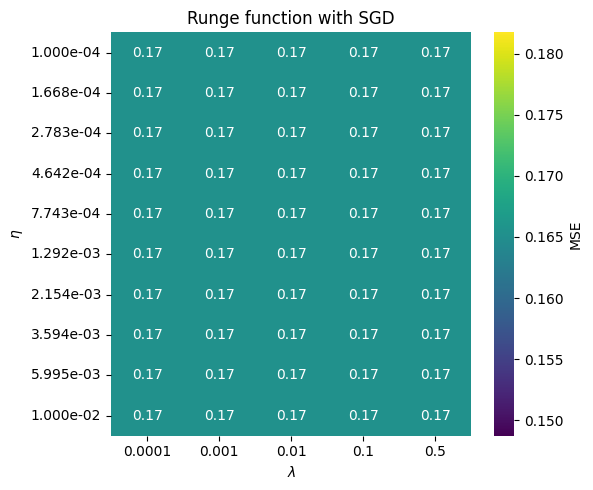

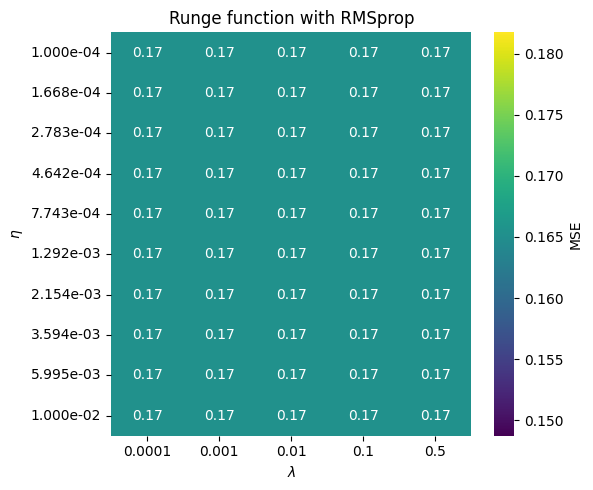

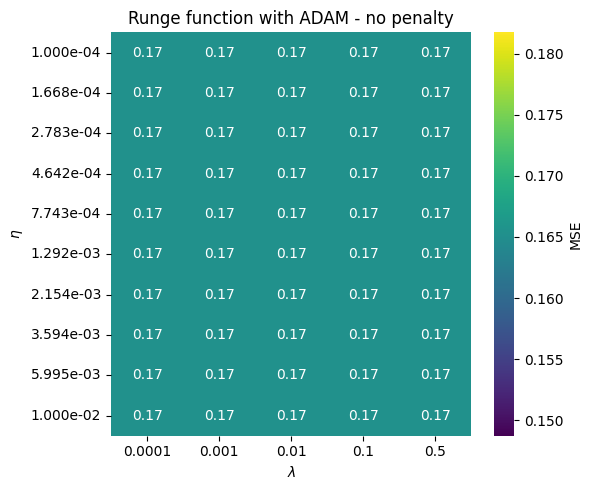

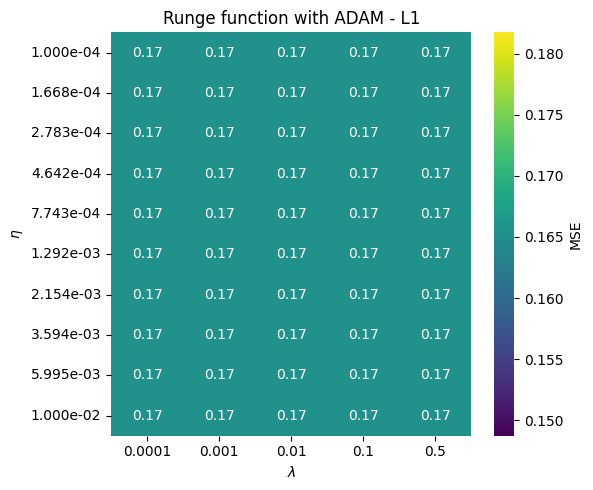

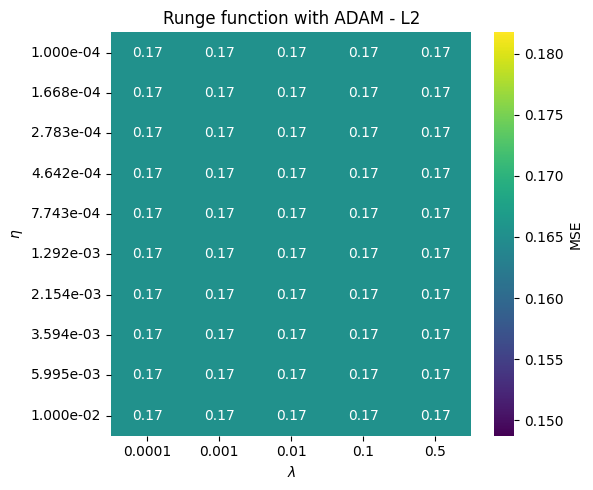

In [6]:
from source.plotting import plot_heatmap

SHOW_PLOT = True

plot_heatmap(results_sgd, title='Runge function with SGD', heat_metric='MSE', filename=f'runge_heatmap_sgd_mse_iter{RUNGE_MAX_ITERATIONS}_momentum{MOMENTUM}_hidden{_dim}', show_plot=SHOW_PLOT)
plot_heatmap(results_rmsprop, title='Runge function with RMSprop', heat_metric='MSE', filename=f'runge_heatmap_rmsprop_mse_iter{RUNGE_MAX_ITERATIONS}_momentum{MOMENTUM}_hidden{_dim}', show_plot=SHOW_PLOT)
plot_heatmap(results_adam_no_penalty, title='Runge function with ADAM - no penalty', heat_metric='MSE', filename=f'runge_heatmap_adamNO_mse_iter{RUNGE_MAX_ITERATIONS}_momentum{MOMENTUM}_hidden{_dim}', show_plot=SHOW_PLOT)
plot_heatmap(results_adam_L1, title='Runge function with ADAM - L1', heat_metric='MSE', filename=f'runge_heatmap_adamL1_mse_iter{RUNGE_MAX_ITERATIONS}_momentum{MOMENTUM}_hidden{_dim}', show_plot=SHOW_PLOT)
plot_heatmap(results_adam_L2, title='Runge function with ADAM - L2', heat_metric='MSE', filename=f'runge_heatmap_adamL2_mse_iter{RUNGE_MAX_ITERATIONS}_momentum{MOMENTUM}_hidden{_dim}', show_plot=SHOW_PLOT)


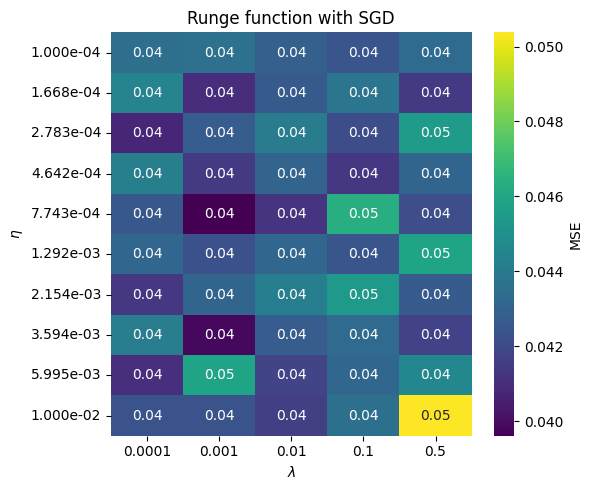

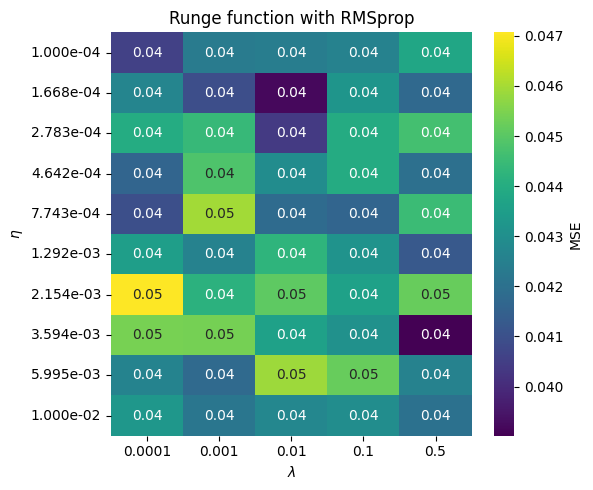

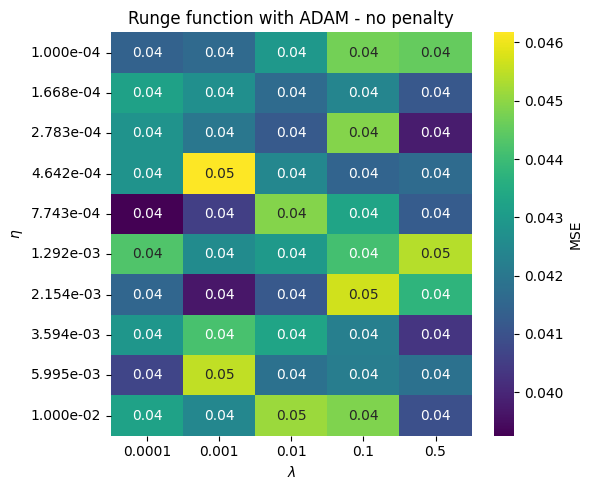

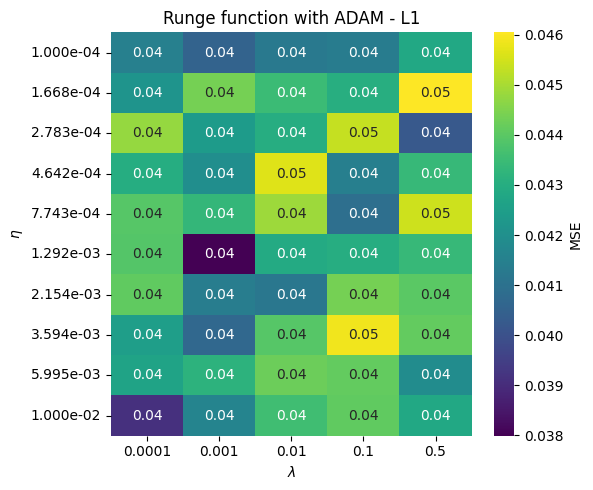

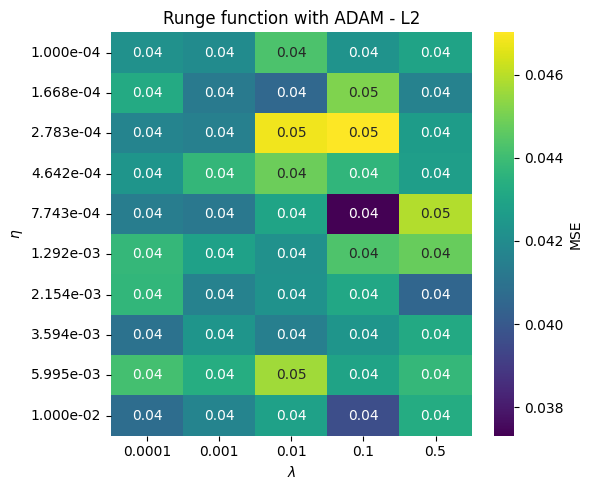

In [7]:
from source.plotting import plot_heatmap

SHOW_PLOT = True

plot_heatmap(results_sgd_50 , title='Runge function with SGD', heat_metric='MSE', filename=f'runge_heatmap_sgd_mse_iter{RUNGE_MAX_ITERATIONS}_momentum{MOMENTUM}_hidden{_dim50}', show_plot=SHOW_PLOT)
plot_heatmap(results_rmsprop_50 , title='Runge function with RMSprop', heat_metric='MSE', filename=f'runge_heatmap_rmsprop_mse_iter{RUNGE_MAX_ITERATIONS}_momentum{MOMENTUM}_hidden{_dim50}', show_plot=SHOW_PLOT)
plot_heatmap(results_adam_no_penalty_50 , title='Runge function with ADAM - no penalty', heat_metric='MSE', filename=f'runge_heatmap_adamNO_mse_iter{RUNGE_MAX_ITERATIONS}_momentum{MOMENTUM}_hidden{_dim50}', show_plot=SHOW_PLOT)
plot_heatmap(results_adam_L1_50 , title='Runge function with ADAM - L1', heat_metric='MSE', filename=f'runge_heatmap_adamL1_mse_iter{RUNGE_MAX_ITERATIONS}_momentum{MOMENTUM}_hidden{_dim50}', show_plot=SHOW_PLOT)
plot_heatmap(results_adam_L2_50 , title='Runge function with ADAM - L2', heat_metric='MSE', filename=f'runge_heatmap_adamL2_mse_iter{RUNGE_MAX_ITERATIONS}_momentum{MOMENTUM}_hidden{_dim50}', show_plot=SHOW_PLOT)


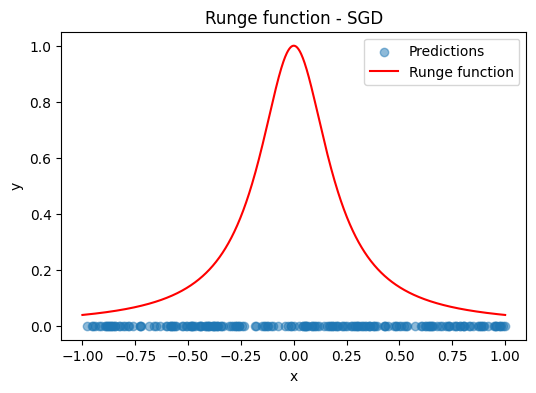

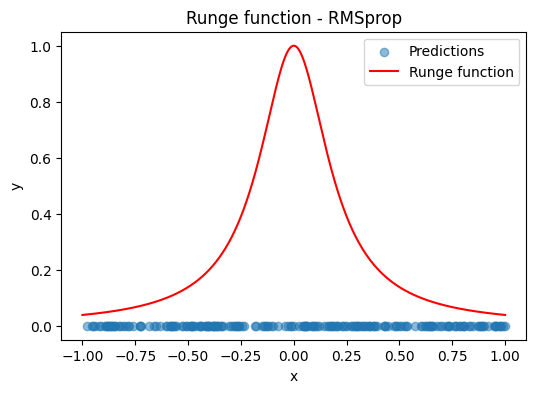

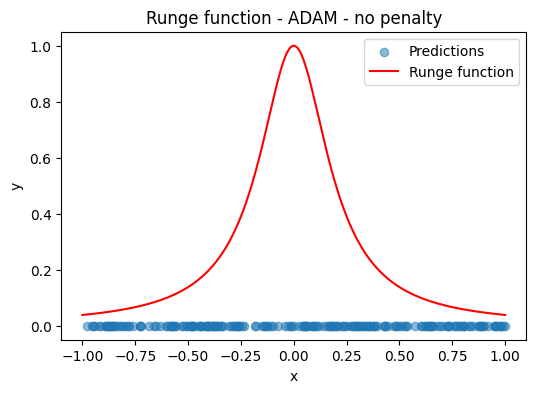

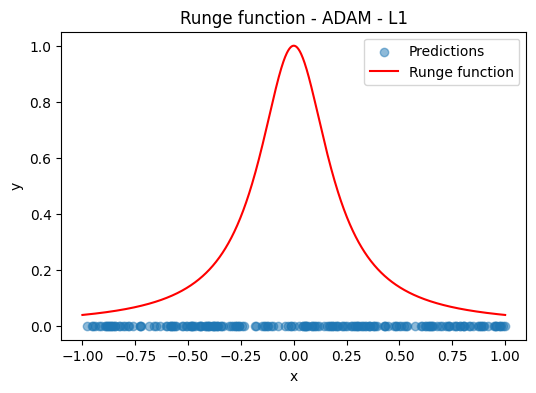

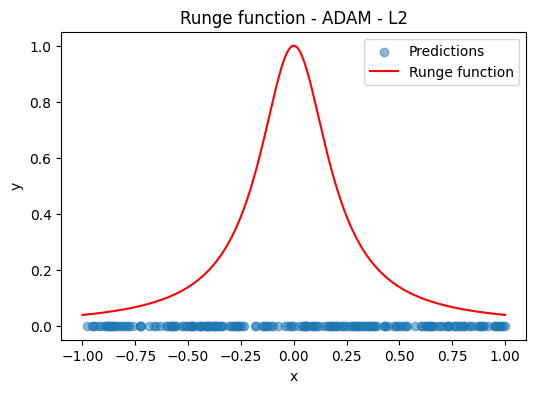

In [8]:
from source.plotting import plot_runges

SHOW_PLOT = True

# SGD
min_row = results_sgd.loc[results_sgd['MSE'].idxmin()]
predictions = min_row['Predictions'] # find predictions for lowest mse
plot_runges(x, y, x_test, predictions, title=f'Runge function - SGD', filename=f'runge_predicted_iter{RUNGE_MAX_ITERATIONS}_momentum{MOMENTUM}_hidden{_dim}', show_plot=SHOW_PLOT)

# RMSprop
min_row = results_rmsprop.loc[results_rmsprop['MSE'].idxmin()]
predictions = min_row['Predictions'] # find predictions for lowest mse
plot_runges(x, y, x_test, predictions, title=f'Runge function - RMSprop', filename=f'runge_predicted_rmsprop_iter{RUNGE_MAX_ITERATIONS}_momentum{MOMENTUM}_hidden{_dim}', show_plot=SHOW_PLOT)

# ADAM - no penalty
min_row = results_adam_no_penalty.loc[results_adam_no_penalty['MSE'].idxmin()]
predictions = min_row['Predictions'] # find predictions for lowest mse
plot_runges(x, y, x_test, predictions, title=f'Runge function - ADAM - no penalty', filename=f'runge_predicted_adamNO_iter{RUNGE_MAX_ITERATIONS}_momentum{MOMENTUM}_hidden{_dim}', show_plot=SHOW_PLOT)

# ADAM - L1
min_row = results_adam_L1.loc[results_adam_L1['MSE'].idxmin()]
predictions = min_row['Predictions'] # find predictions for lowest mse
plot_runges(x, y, x_test, predictions, title=f'Runge function - ADAM - L1', filename=f'runge_predicted_adamL1_iter{RUNGE_MAX_ITERATIONS}_momentum{MOMENTUM}_hidden{_dim}', show_plot=SHOW_PLOT)

# ADAM - L2
min_row = results_adam_L2.loc[results_adam_L2['MSE'].idxmin()]
predictions = min_row['Predictions'] # find predictions for lowest mse
plot_runges(x, y, x_test, predictions, title=f'Runge function - ADAM - L2', filename=f'runge_predicted_adamL2_iter{RUNGE_MAX_ITERATIONS}_momentum{MOMENTUM}_hidden{_dim}', show_plot=SHOW_PLOT)

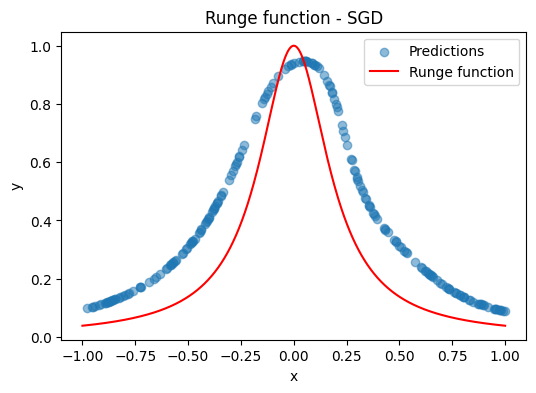

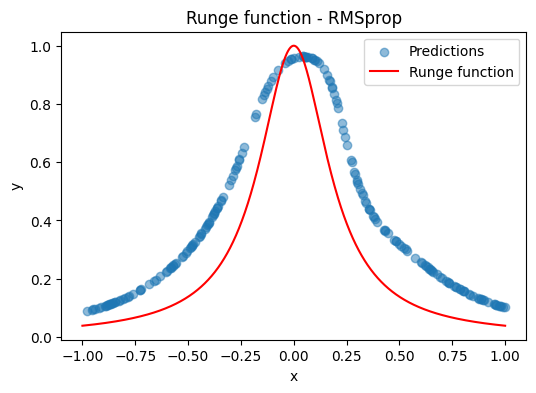

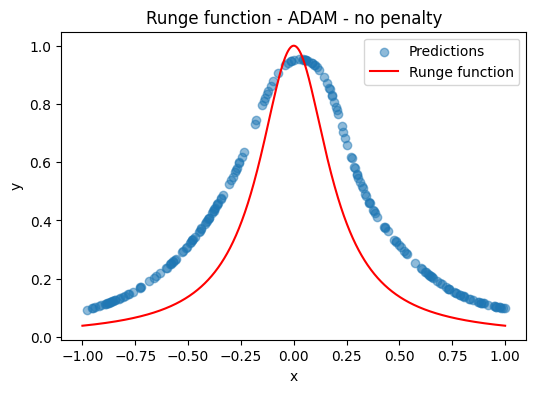

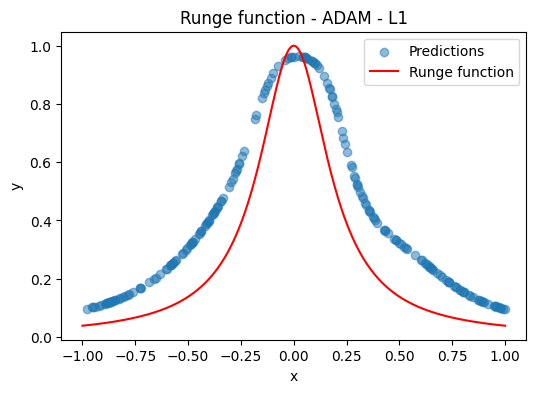

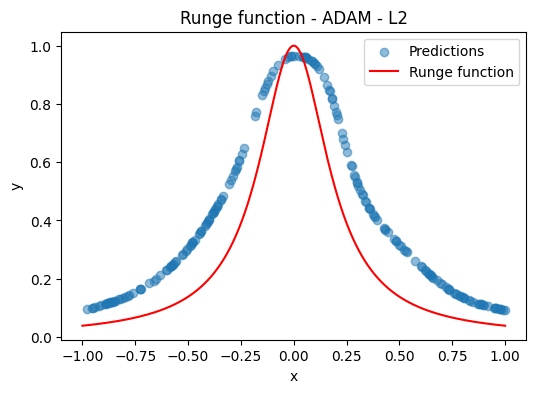

In [9]:
from source.plotting import plot_runges

SHOW_PLOT = True

# SGD
min_row = results_sgd_50.loc[results_sgd_50['MSE'].idxmin()]
predictions = min_row['Predictions'] # find predictions for lowest mse
plot_runges(x, y, x_test, predictions, title=f'Runge function - SGD', filename=f'runge_predicted_iter{RUNGE_MAX_ITERATIONS}_momentum{MOMENTUM}_hidden{_dim50}', show_plot=SHOW_PLOT)

# RMSprop
min_row = results_rmsprop_50.loc[results_rmsprop_50['MSE'].idxmin()]
predictions = min_row['Predictions'] # find predictions for lowest mse
plot_runges(x, y, x_test, predictions, title=f'Runge function - RMSprop', filename=f'runge_predicted_rmsprop_iter{RUNGE_MAX_ITERATIONS}_momentum{MOMENTUM}_hidden{_dim50}', show_plot=SHOW_PLOT)

# ADAM - no penalty
min_row = results_adam_no_penalty_50.loc[results_adam_no_penalty_50['MSE'].idxmin()]
predictions = min_row['Predictions'] # find predictions for lowest mse
plot_runges(x, y, x_test, predictions, title=f'Runge function - ADAM - no penalty', filename=f'runge_predicted_adamNO_iter{RUNGE_MAX_ITERATIONS}_momentum{MOMENTUM}_hidden{_dim50}', show_plot=SHOW_PLOT)

# ADAM - L1
min_row = results_adam_L1_50.loc[results_adam_L1_50['MSE'].idxmin()]
predictions = min_row['Predictions'] # find predictions for lowest mse
plot_runges(x, y, x_test, predictions, title=f'Runge function - ADAM - L1', filename=f'runge_predicted_adamL1_iter{RUNGE_MAX_ITERATIONS}_momentum{MOMENTUM}_hidden{_dim50}', show_plot=SHOW_PLOT)

# ADAM - L2
min_row = results_adam_L2_50.loc[results_adam_L2_50['MSE'].idxmin()]
predictions = min_row['Predictions'] # find predictions for lowest mse
plot_runges(x, y, x_test, predictions, title=f'Runge function - ADAM - L2', filename=f'runge_predicted_adamL2_iter{RUNGE_MAX_ITERATIONS}_momentum{MOMENTUM}_hidden{_dim50}', show_plot=SHOW_PLOT)